# Hierarchical Bradley--Terry Models: AFL Analysis

The purpose of this notebook is to analyse match data from the Australian Football League (AFL) using (Hierarchical) Bradley--Terry models.
These models allow for various parameterisations of *home-ground advantage* (HGA) to be explored.
They have been extended to allow for neutral venues, nonparametric dynamic effects, and arbitrary relationship structures between teams.

This notebook goes through the data loading, model fitting, and analysis steps for my Honours thesis on HBT models.
We look at the last 20 years of AFL matches and then a case study on the effects of the COVID-19 pandemic.
We assume that the data consists of *paired comparisons* (e.g., Brisbane Lions v Richmond Tigers) with *binary outcomes* (i.e., win-or-lose) in *discrete time blocks* (i.e., years, seasons).
For example, each datum should look like: 
```
(home_team, away_team, home_score, away_score, season)
```

In our BT model framework, we have two types of parameters:
- The **strength** $\theta_{it}$ of team $i$ in time block $t$
- The **HGA** $\alpha_{k}$ where the meaning of the subscript $k$ depends on the model

By default, the dynamic extension allows the team strengths to vary while the HGAs remain constant over time.
See my thesis for a formal definition and discussion of these models.

## Init

In [1]:
# This block is needed to treat our code like a package (for now)
# When it's set up properly later, this will be unnecessary

import os
import sys

root_dir = os.path.dirname(os.path.abspath(os.curdir))
src_dir = os.path.join(root_dir, 'src')
sys.path.append(src_dir)
# print(sys.path[-1])

In [2]:
import numpy as np
from numpy import ndarray, exp, log
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt
import seaborn as sns

# Our models and things
from DynamicModel import *
from hypothesis_tests import *
from utils import *
from visualisation import *

# To format the AFL data for use in our models
from data_utils_afl import *

rng = np.random.default_rng(0)
sns.set_theme(style="darkgrid")

## Data loading and EDA

We first need to load the data.
Some EDA is done to check the teams and venues are as expected, as well as check the tenants and neutral venues are correct.
See this [competition timeline](https://en.wikipedia.org/wiki/History_of_the_Australian_Football_League#History) for a visual overview of teams entering and leaving the league.

Match data is sourced from the ["AFL Data Analysis" GitHub repository](https://github.com/akareen/AFL-Data-Analysis) which itself is sourced from [AFLTables](https://afltables.com/afl/afl_index.html).
Venue and tenant data was manually compiled from a few sources: [Austadiums](https://www.austadiums.com/sport/comp/afl/teams) and [Wikipedia](https://en.wikipedia.org/wiki/List_of_Australian_Football_League_grounds#Current_grounds).
Note that some teams have commercial deals in place to play certain games at some venue, but we do not consider these venues as home grounds for those teams.

Note: we consider a match *neutral* if the given venue is the home ground of neither team (no HGA) OR both teams (neutralised HGA).

### Loading

In [3]:
# Get tenants information for checking neutral venues
tenants_path = "../data/afl/afl_tenants.csv"
tenants = pd.read_csv(tenants_path)
tenants.end_year = tenants.end_year.fillna(2026).astype("int64")    # Fill empty end years with 2026
tenants = tenants[tenants.deal == 0]                                # We do NOT consider commercial deals as home games

# Need to pass aliases since North Melbourne was called Kangaroos until 2008
aliases = {"Kangaroos": "North Melbourne", "Greater Western Sydney": "GWS Giants"}

In [4]:
# Get team location information for later
team_path = "../data/afl/afl_teams.csv"
team_locations = pd.read_csv(team_path, index_col=0)

In [5]:
# Load the long-form AFL data
path = "../data/afl/akareen-matches/"
start, end = 2005, 2024
df = load_data_afl(
    path, 
    start_year=start, end_year=end, 
    tenants=tenants, include_venue=True, aliases=aliases, 
    nominal_home=False, fix_swapped=True,
    print_missing_data=False
)

# Load the pre-cleaned df
# path = "../data/afl/afl_matches_clean.csv"
# df = pd.read_csv(path)

In [6]:
df.head(30)

,home,away,home_score,away_score,is_neutral,year,venue
0,Brisbane Lions,St Kilda,116.0,93.0,0,2005,Gabba
1,North Melbourne,Carlton,105.0,85.0,1,2005,Docklands
2,Melbourne,Essendon,103.0,57.0,1,2005,M.C.G.
3,Fremantle,Port Adelaide,88.0,53.0,0,2005,Subiaco
4,Sydney,Hawthorn,118.0,55.0,0,2005,S.C.G.
5,Richmond,Geelong,98.0,160.0,0,2005,M.C.G.
6,Adelaide,West Coast,53.0,64.0,0,2005,Football Park
7,Collingwood,Western Bulldogs,80.0,112.0,0,2005,M.C.G.
8,Carlton,Essendon,110.0,106.0,1,2005,M.C.G.
9,Western Bulldogs,Melbourne,111.0,137.0,0,2005,Docklands


Note that the dataset from the link above has some small errors. In particular, I've noticed that the scraper has a bug when there is a draw in any of the finals rounds, since ties are played into overtime rather than drawn. For example, the [2007 semi-final of West Coast v Collingwood](https://afltables.com/afl/stats/games/2007/041820070914.html). These may need to be fixed manually, though their frequency is so low that it shouldn't be of much consequence otherwise (as missing data rows are skipped).

### EDA (optional)

The data has been loaded successfully. Let's look at some interesting facts while checking everything is as expected.

In [28]:
print(f"Total games played ({start}-{end}): {df.shape[0]}")

Total games played (2005-2024): 3970


In [29]:
print("Number of games played per team")
(df.home.value_counts() + df.away.value_counts()).sort_values(ascending=False)

Number of games played per team


home
Geelong             480
Sydney              477
Collingwood         471
Hawthorn            465
West Coast          463
Western Bulldogs    461
Port Adelaide       457
Adelaide            455
Brisbane Lions      455
St Kilda            454
Fremantle           453
Richmond            453
Melbourne           450
North Melbourne     450
Carlton             447
Essendon            443
Gold Coast          305
GWS Giants          301
Name: count, dtype: int64

In [30]:
print("Number of games played per season")
df.year.value_counts().sort_index()

Number of games played per season


year
2005    185
2006    185
2007    185
2008    185
2009    185
2010    186
2011    196
2012    207
2013    207
2014    207
2015    206
2016    207
2017    207
2018    207
2019    207
2020    162
2021    207
2022    207
2023    216
2024    216
Name: count, dtype: int64

In [31]:
print("Number of games played per venue")
df.value_counts("venue").sort_values(ascending=False)

Number of games played per venue


venue
M.C.G.                961
Docklands             891
Subiaco               302
Adelaide Oval         262
Gabba                 258
Football Park         207
S.C.G.                190
Carrara               185
Kardinia Park         158
Perth Stadium         157
Sydney Showground     102
York Park              81
Manuka Oval            50
Stadium Australia      45
Bellerive Oval         40
Marrara Oval           27
Cazaly's Stadium       14
Eureka Stadium         14
Traeger Park           10
Norwood Oval            4
Wellington              3
Jiangwan Stadium        3
Summit Sports Park      3
Princes Park            1
Blacktown               1
Riverway Stadium        1
Name: count, dtype: int64

In [32]:
print("Number of non-neutral and neutral games")
df.is_neutral.value_counts()

Number of non-neutral and neutral games


is_neutral
0    2817
1    1153
Name: count, dtype: int64

In [33]:
n_ties = len(df[df.home_score == df.away_score])
print(f"Number of tied games ({start}-{end}): {n_ties}")
print(f"This is only {n_ties/len(df):.2%} of the total games!")

Number of tied games (2005-2024): 36
This is only 0.91% of the total games!


In [34]:
unique_homes = list(set(tenants.venue[tenants.deal == 0].to_list()))
unique_deals = list(set(tenants.venue[tenants.deal == 1].to_list()))

In [35]:
tenants_map = {team: df for team, df in tenants.groupby("team")}

def is_home_venue(team, venue, year):
    if team not in tenants_map:
        return False
    df = tenants_map[team]
    return ((df["venue"] == venue) &
            (df["start_year"] <= year) &
            (df["end_year"] >= year) &
            (df["deal"] == 0)).any()

def is_deal_venue(team, venue, year):
    if team not in tenants_map:
        return False
    df = tenants_map[team]
    return ((df["venue"] == venue) &
            (df["start_year"] <= year) &
            (df["end_year"] >= year) &
            (df["deal"] == 1)).any()

def classify_game(row):
    h, a, v, y = row["home"], row["away"], row["venue"], row["year"]

    h_home = is_home_venue(h, v, y)
    a_home = is_home_venue(a, v, y)

    h_deal = is_deal_venue(h, v, y)
    a_deal = is_deal_venue(a, v, y)

    # --- categories
    if h_home and not a_home:
        return "home"
    elif h_home and a_home:
        return "both home"
    elif not h_home and not a_home:
        return "neither home"
    else:
        return "other"

In [36]:
df["game_type"] = df.apply(classify_game, axis=1)
df.game_type.value_counts()

game_type
home            2817
both home        673
neither home     480
Name: count, dtype: int64

In [37]:
home_games    = df[df["game_type"] == "home"]
both_games    = df[df["game_type"] == "both home"]
neutral_games = df[df["game_type"] == "neither home"]
other_games   = df[df["game_type"] == "other"]

In [38]:
both_games.venue.value_counts()

venue
M.C.G.           386
Docklands        208
Subiaco           26
Adelaide Oval     21
Football Park     19
Perth Stadium     13
Name: count, dtype: int64

In [39]:
neutral_games.venue.value_counts()

venue
York Park             81
Docklands             74
Carrara               52
Manuka Oval           50
M.C.G.                43
Bellerive Oval        40
Marrara Oval          27
Gabba                 27
Cazaly's Stadium      14
Eureka Stadium        14
Adelaide Oval         13
Traeger Park          10
Perth Stadium          7
Sydney Showground      5
S.C.G.                 4
Norwood Oval           4
Wellington             3
Jiangwan Stadium       3
Summit Sports Park     3
Stadium Australia      2
Kardinia Park          2
Blacktown              1
Riverway Stadium       1
Name: count, dtype: int64

In [40]:
other_games.venue.value_counts()

Series([], Name: count, dtype: int64)

In [41]:
other_games.sort_values(["home", "venue"]).iloc[120:,:]

,home,away,home_score,away_score,is_neutral,year,venue,game_type


It seems that 2817 games were played at true home grounds and 190 were played as part of commercial deals, making the 3007 total home games.

Both teams shared the same home ground in 673 games - quite a lot!

The remaining 290 games were neutral because both teams were away. These could be interesting to look into.

In [42]:
dummy = neutral_games[~neutral_games.venue.isin(unique_homes)].sort_values(["venue", "year", "home"])
dummy.shape[0]

251

For neutral games played at usual home venues we have a combination of reasons:
- COVID-19 pushing games outside Melbourne in 2020, 2021
- Gather Round in 2023, 2024 (Adelaide)
- Carrara has a complicated history of short deals
- Finals matches being played at the MCG

The remaining special games highlight some interesting exhibition matches and events in AFL, such as [Gather Round](https://en.wikipedia.org/wiki/Gather_Round) and other commercial deals like [Port Adelaide playing in Shanghai](https://en.wikipedia.org/wiki/Jiangwan_Stadium#Australian_rules_football). These would be interesting to tabulate in an appendix.

In [43]:
# If we want to look at nominal home team effects, then set the "both" games or all games back to non-neutral
# df.loc[df.game_type == 'both home', 'is_neutral'] = 0
df.drop("game_type", axis=1, inplace=True)

In [44]:
# An example look at games between two teams over the years
team1, team2 = "North Melbourne", "Geelong"
df[((df.home == team1) & (df.away == team2)) | ((df.home == team2) & (df.away == team1))].sort_values(["is_neutral", "venue", "year"]).head(10)

,home,away,home_score,away_score,is_neutral,year,venue
528,North Melbourne,Geelong,91.0,118.0,0,2007,Docklands
635,North Melbourne,Geelong,114.0,127.0,0,2008,Docklands
1333,North Melbourne,Geelong,131.0,114.0,0,2012,Docklands
1529,North Melbourne,Geelong,108.0,112.0,0,2013,Docklands
1667,North Melbourne,Geelong,96.0,86.0,0,2013,Docklands
1878,North Melbourne,Geelong,79.0,111.0,0,2014,Docklands
2048,North Melbourne,Geelong,120.0,79.0,0,2015,Docklands
2236,North Melbourne,Geelong,74.0,105.0,0,2016,Docklands
2356,North Melbourne,Geelong,111.0,112.0,0,2017,Docklands
2824,North Melbourne,Geelong,80.0,104.0,0,2019,Docklands


In [45]:
# Save the cleaned df
# df.drop("game_type", axis=1).to_csv("../data/afl/afl_matches_clean.csv", index=False)

### Converting to win matrices

The data needs to be converted into win matrices for the models.

In [7]:
dummy = df.drop("venue", axis=1)
df_van = make_time_blocked_win_matrix(dummy.drop("is_neutral", axis=1))
df_cha = make_time_blocked_venue_win_matrices(dummy)

To demonstrate what a win matrix looks like, the 2010 results have been plotted below.
A few things to notice:
- GWS Giants and Gold Coast have zero games as they did not exist in the AFL yet
- Ties are allocated as half a win to each team, which explains the rare ".5"s
- Each pair plays at least one game

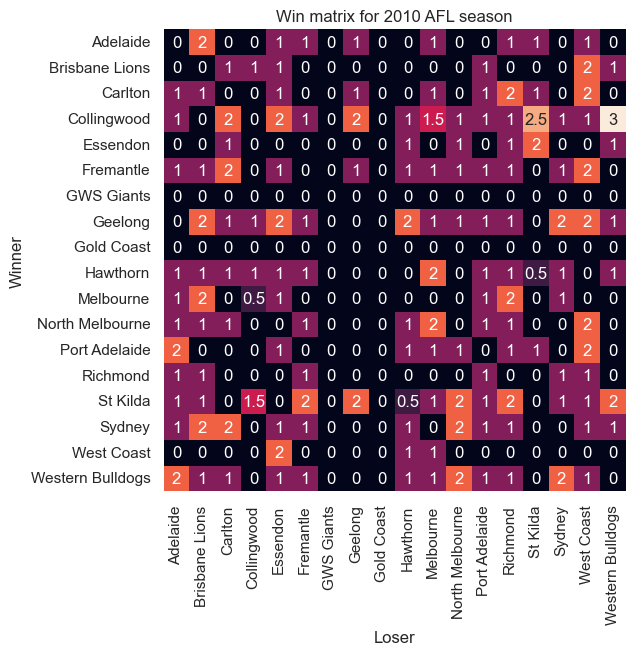

In [8]:
# example_year = [i for i in df_van.keys()][-1]
example_year = 2010
plt.figure(figsize=(6,6))
sns.heatmap(df_van[example_year], annot=True, fmt="g", cbar=False, square=True)
plt.xlabel("Loser")
# plt.xticks(rotation=60, ha="right")
plt.ylabel("Winner")
plt.title(f"Win matrix for {example_year} AFL season")
plt.show()

In [9]:
start, end = 2005, 2024
basic_van = {i: df_van[i] for i in range(start, end+1)}
basic_hga = {i: df_cha[i] for i in range(start, end+1)}

## Basic model fitting

Before considering any "hierarchical" models, let's just apply some basic BT models to the AFL data.
These are our vanilla (VAN), common HGA (CHA), and team-specific HGA (TSA) models.
We hope to get some understanding of how home-ground advantages exist in the AFL.

The syntax is designed to be similar to packages like `scikit-learn` with a simple `fit()` method that takes the required data.
The VAN model just needs the overall win matrices, while any home-ground model needs the wins to be further partitioned by the venue types.

In [10]:
van = VANBT().fit(basic_van)
cha = CHABT().fit(basic_hga)
tsa = TSABT().fit(basic_hga)

Ideally, the models all fit successfully!
At time of writing, the optimisation of the code is not at the standard I'd like, so fitting might be slow.
Regardless, we can check a few things of interest, such as the metadata and fit summaries of each model.
It's also possible to choose which team should be the constraint, such as the estimated worst on average or first alphabetically.

In [11]:
models = (van, cha, tsa)
# for model in models: model.rebase_abilities("custom", 'Brisbane Lions')
for model in models: model.summary(verbose=2, wrap_len=135)

MODEL SUMMARY: VANBT

Model Statistics
-------------------------
# Teams:   18              # Obs:     3970
# Times:   20              # Params:  327
LLH:       -2068.684
AIC:       4791.369
BIC:       6847.061
# Iter:    46

Constraint team: Adelaide

Team Rankings
-------------------------
                      2005  [SE_2005]      2006  [SE_2006]      2007  [SE_2007]      2008  [SE_2008]      2009  [SE_2009]      2010  \
Geelong             -0.907      0.636    -1.285      0.663     1.593      0.696     2.371      0.893     1.306      0.744     1.612   
Sydney              -0.111      0.626    -0.537      0.649    -0.059      0.622     0.113      0.645    -1.307      0.692     0.855   
Collingwood         -2.563      0.724    -0.764      0.648     0.172      0.604    -0.041      0.622     0.141      0.630     2.217   
Hawthorn            -2.569      0.730    -1.803      0.685     0.227      0.599     1.393      0.707    -1.265      0.670     0.746   
Western Bulldogs    -1.142      

In [18]:
# Interpret the common HGA parameter
print(f"Increase in odds in favour of home team: {np.exp(cha._calculate_odds(0,0,cha._get_hga_param())):.2f}")
print(f"Probability of home team winning against evenly matched opponent: {cha._calculate_prob(0,0,cha._get_hga_param()):.1%}")

Increase in odds in favour of home team: 1.70
Probability of home team winning against evenly matched opponent: 63.0%


In [19]:
ranking = cha.get_ranking("Average", include_errors=False, mean_center=True, as_ranks=False).round(3)
# sns.barplot(ranking.drop("Average", axis=1).var(axis=1).sort_values(ascending=False), orient="y")
# plt.show()
# (ranking.max() - ranking.min()).sort_values(ascending=False)
# ranking

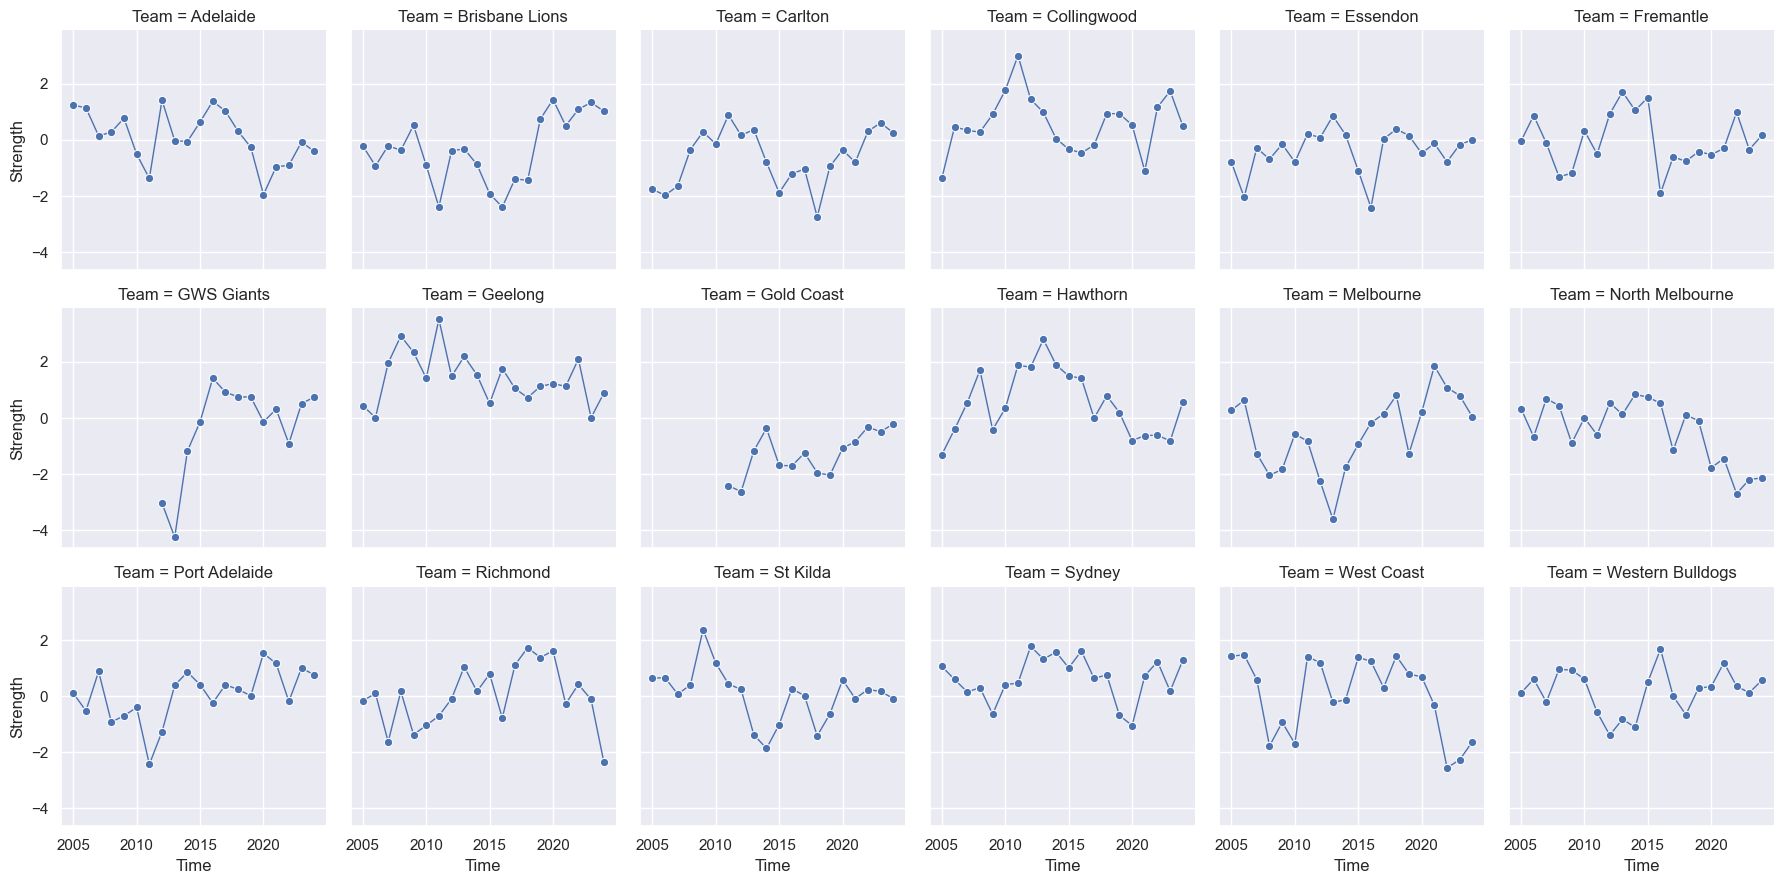

In [20]:
plot_strengths(cha, "grid", n_grid_cols = 6)

We also provide some (basic) plotting functionality to help explore things out of the box.
An experienced user is encouraged to adjust or make their own plots for their needs.

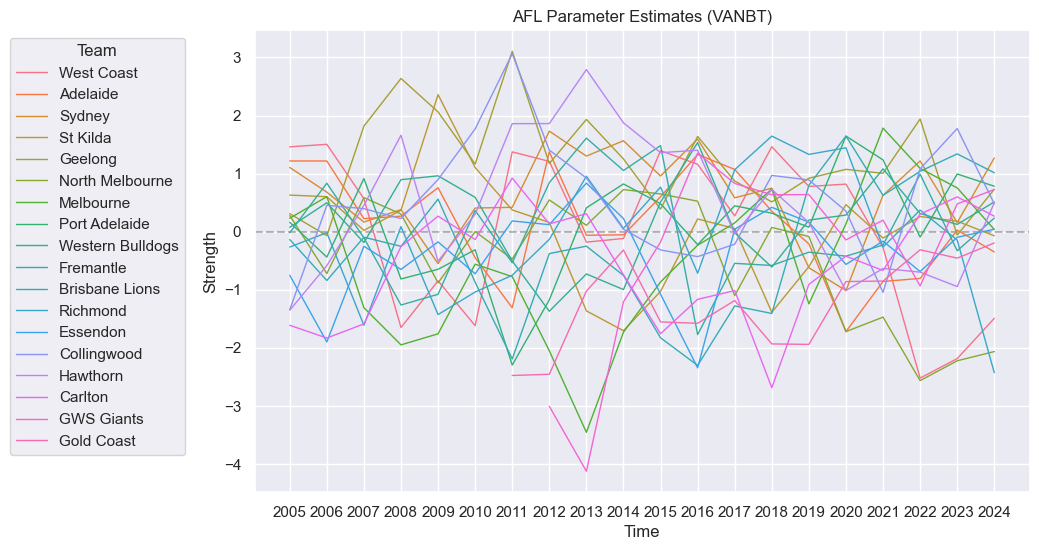

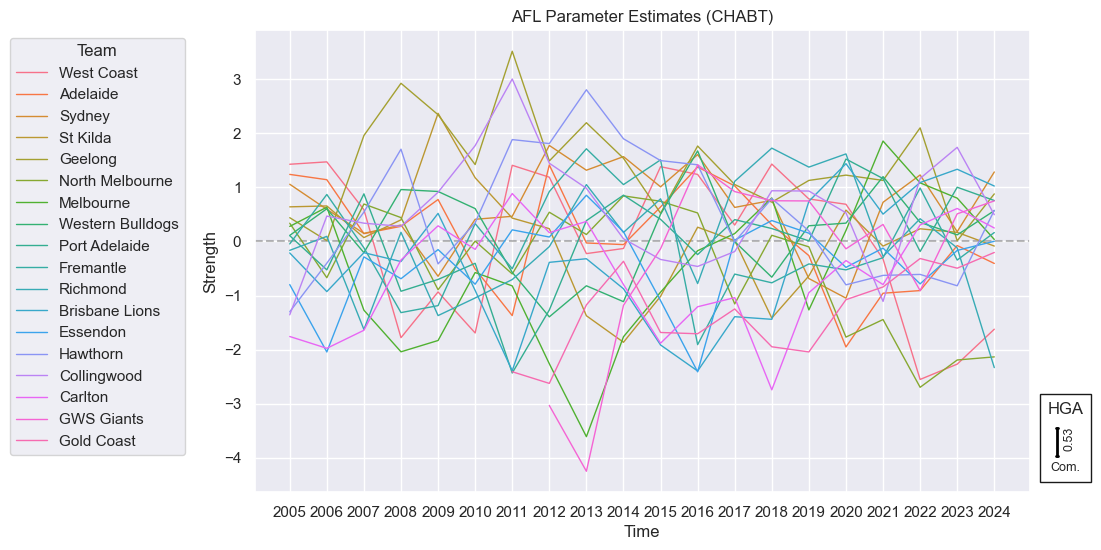

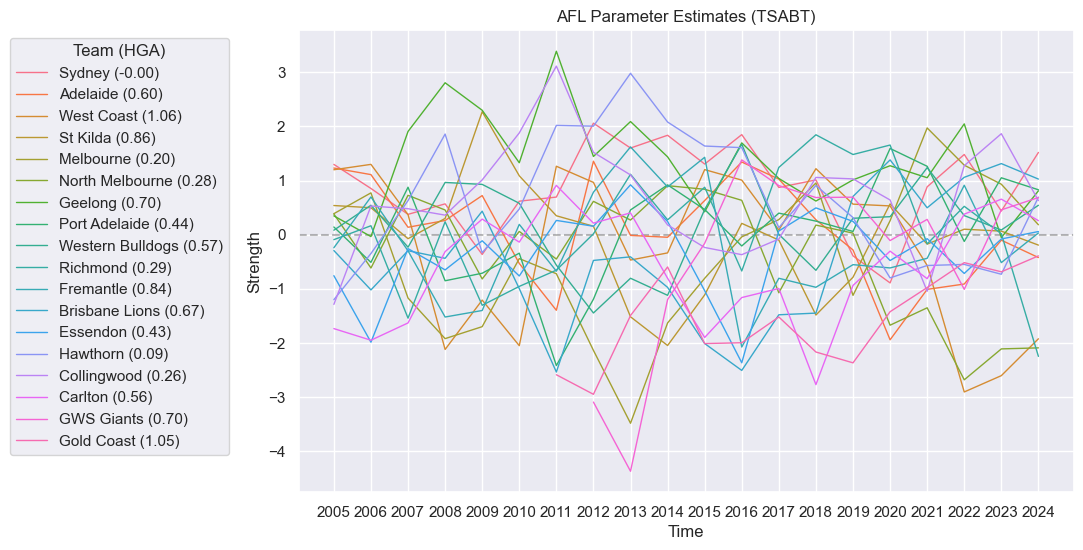

In [21]:
for model in models:
    plt.figure(figsize=(10, 6))
    ax = plot_strengths(model)
    ax = plt.gca()
    sns.move_legend(ax, "upper right", bbox_to_anchor=(-0.08, 1))
    plt.title(f"AFL Parameter Estimates ({model.__class__.__name__})")
    # plt.savefig(f"ch4_afl_basic_{model.__class__.__name__}", bbox_inches="tight")
    # plt.xticks(rotation=90)
    plt.show()

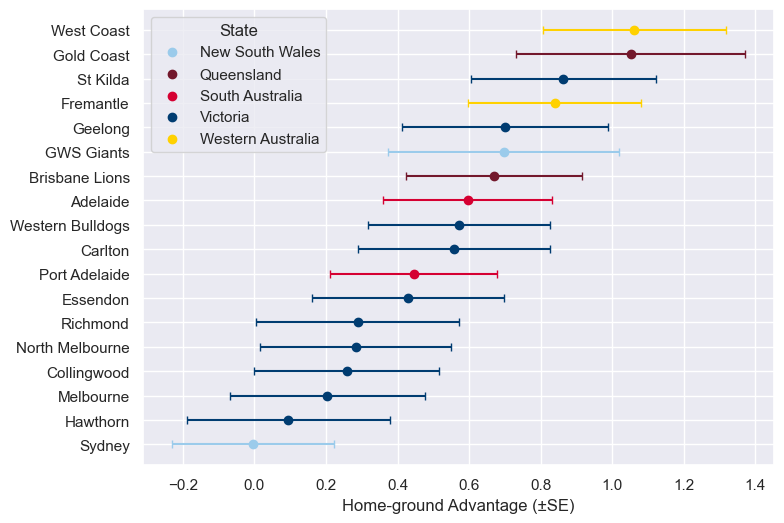

In [22]:
# Make a simple supporting plot to visualise magnitudes of team-specific HGAs
hgas = tsa.get_hgas(include_errors=True).sort_values("HGA", ascending=True)
hgas["State"] = team_locations.state
dummy = hgas.reset_index().rename(columns={"index": "Team"})

states = dummy["State"].unique()

# https://en.wikipedia.org/wiki/Australian_state_and_territory_colours
color_map = {
    'New South Wales': "#9bcbeb",
    'Queensland': "#73182c",
    'South Australia': "#d50032",
    'Victoria': "#003c71",
    'Western Australia': "#ffd100"
}

# colors = plt.cm.tab10(range(len(states)))
# color_map = dict(zip(states, colors))

plt.figure(figsize=(8, len(dummy) * 0.3))

for i, row in dummy.iterrows():
    plt.errorbar(
        x=row["HGA"],
        y=i,
        xerr=row["[SE]"],
        fmt="o",
        color=color_map[row["State"]],
        capsize=3
    )

plt.yticks(range(len(dummy)), dummy["Team"])

# legend
for state, color in color_map.items():
    plt.scatter([], [], color=color, label=state)
plt.legend(title="State")

plt.xlabel(f"Home-ground Advantage ({u'\u00b1'}SE)")
plt.tight_layout()
plt.show()

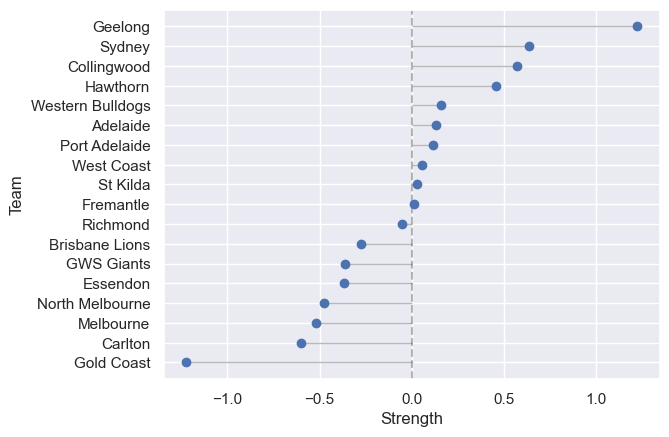

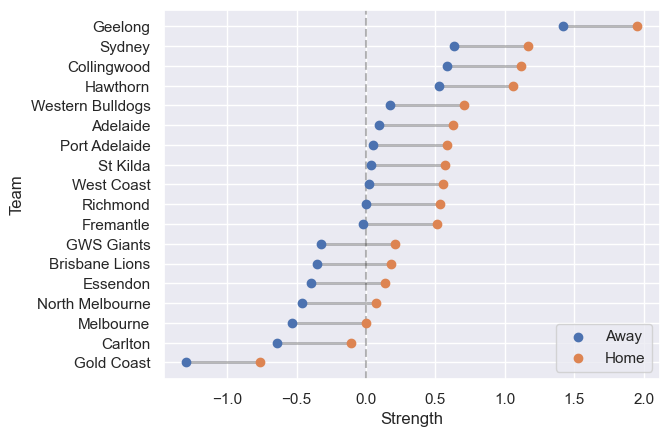

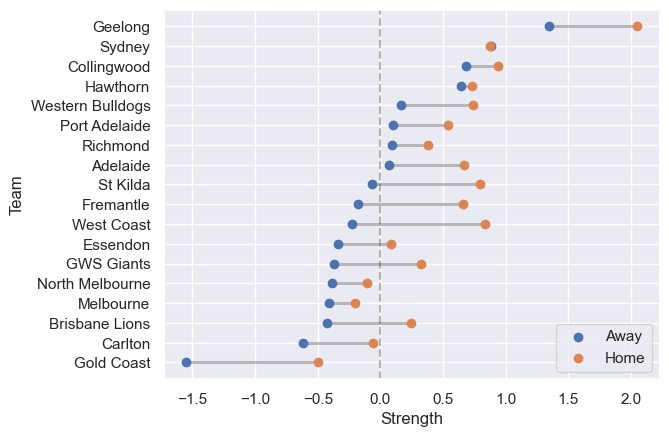

In [24]:
for model in models:
    plot_strengths(model, 'average', mean_centered=True)
    # plt.savefig(f"ch4_afl_basic_{model.__class__.__name__}_avg", bbox_inches="tight")
    plt.show()

## Hypothesis testing

When models are *nested*, we can compare them by LRT (which becomes a comparison of deviance) and interpretting *p*-values for fit adequacy.
The implementation supports model diagnostics and comparisons.

In [25]:
simple_report(van, cha)
simple_report(cha, tsa)
simple_report(van, tsa)
print()

Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
VANBT      327   2068.68      4791.37      6847.06     
CHABT      328   2005.46      4666.91      6728.89      126.457    2.44e-29 ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
CHABT      328   2005.46      4666.91      6728.89     
TSABT      345   1994.40      4678.81      6847.66      22.104     0.181 

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
VANBT      327   2068.68      4791.37      6847.06     
TSABT      345   1994.40      4678.81      6847.66      148.561    1.41e-22 ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1



The outputs suggest that there is extremely strong evidence of a common home-ground effect ($p \approx 0$), and furthermore moderate evidence of a team-specific home-ground effect ($p < 0.05$). One could argue that either choice of CHA or TSA model would be reasonable.

## Nominal Home Team Advantage

Something interesting to consider is that the AFL fixture always designates a "home" and "away" team, even when we would call this "neutral" by our definition.
Is there still an inherent advantage in these nominal teams, despite having no edge in venue familiarity and/or travel burden?

It would be good to fit CHA models on the different subsets of neutral games, but these win matrices aren't strongly connected.
The best we can do is change them from neutral to non-neutral and refit the entire model.

In [46]:
# Reload data without swapping
df_nom = load_data_afl(
    path, start_year=start, end_year=end, 
    tenants=tenants, aliases=aliases, include_venue=True
)

In [47]:
df_nom["game_type"] = df_nom.apply(classify_game, axis=1)
df_nom.game_type.value_counts()

game_type
home            2686
both home        673
neither home     480
other            131
Name: count, dtype: int64

In [48]:
df_nom = df_nom.drop(["venue", "game_type"], axis=1)

# Set all games to be neutral, ie, always use the nominal home team
df_nom.is_neutral = 0

# dummy = df_nom.drop("venue", axis=1)
df_nom_van = make_time_blocked_win_matrix(df_nom.drop("is_neutral", axis=1))
df_nom_hga = make_time_blocked_venue_win_matrices(df_nom)

In [49]:
# van_nom = VANBT().fit(df_nom_van)
cha_nom = CHABT().fit(df_nom_hga)
tsa_nom = TSABT().fit(df_nom_hga)

In [50]:
print(f"Increase in odds in favour of home team: {np.exp(cha_nom._calculate_odds(0,0,cha_nom._get_hga_param())):.2f}")
print(f"Probability of home team winning against evenly matched opponent: {cha_nom._calculate_prob(0,0,cha_nom._get_hga_param()):.1%}")

Increase in odds in favour of home team: 1.49
Probability of home team winning against evenly matched opponent: 59.9%


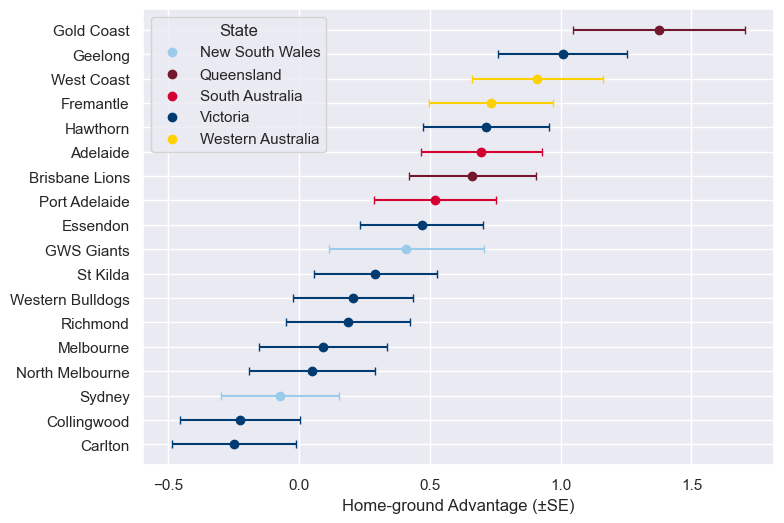

In [51]:
hgas_nom = tsa_nom.get_hgas(include_errors=True).sort_values("HGA", ascending=True)
hgas_nom["State"] = team_locations.state
dummy = hgas_nom.reset_index().rename(columns={"index": "Team"})
states = dummy["State"].unique()

# https://en.wikipedia.org/wiki/Australian_state_and_territory_colours
color_map = {
    'New South Wales': "#9bcbeb",
    'Queensland': "#73182c",
    'South Australia': "#d50032",
    'Victoria': "#003c71",
    'Western Australia': "#ffd100"
}

# colors = plt.cm.tab10(range(len(states)))
# color_map = dict(zip(states, colors))

plt.figure(figsize=(8, len(dummy) * 0.3))

for i, row in dummy.iterrows():
    plt.errorbar(
        x=row["HGA"],
        y=i,
        xerr=row["[SE]"],
        fmt="o",
        color=color_map[row["State"]],
        capsize=3
    )

plt.yticks(range(len(dummy)), dummy["Team"])

# legend
for state, color in color_map.items():
    plt.scatter([], [], color=color, label=state)
plt.legend(title="State")

plt.xlabel(f"Home-ground Advantage ({u'\u00b1'}SE)")
plt.tight_layout()
plt.show()

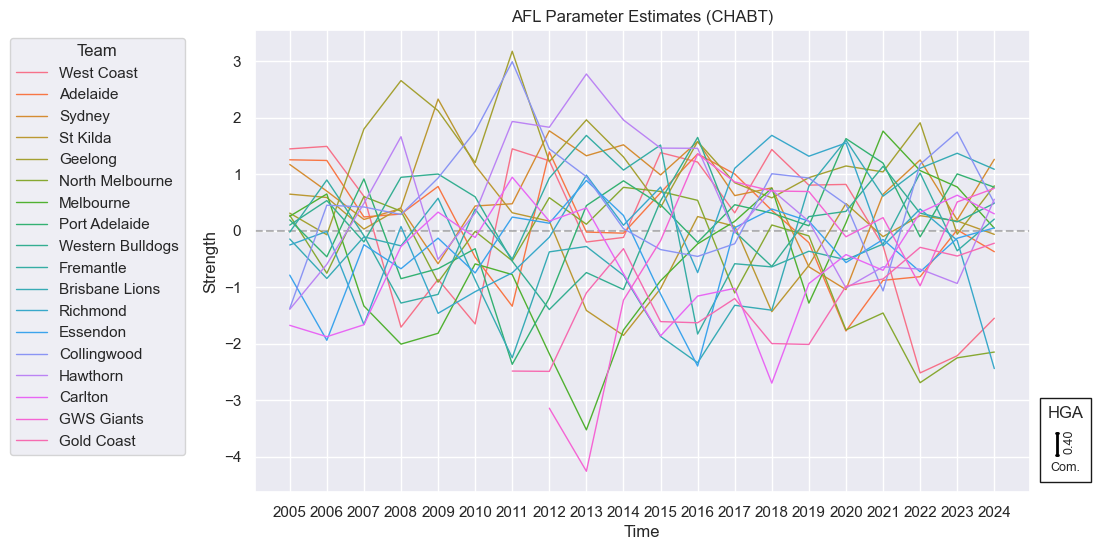

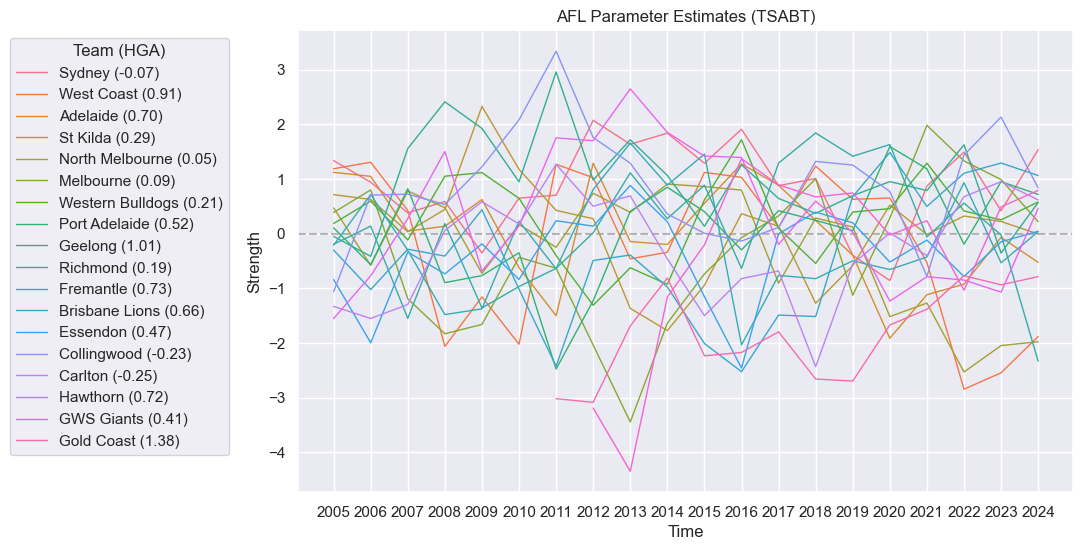

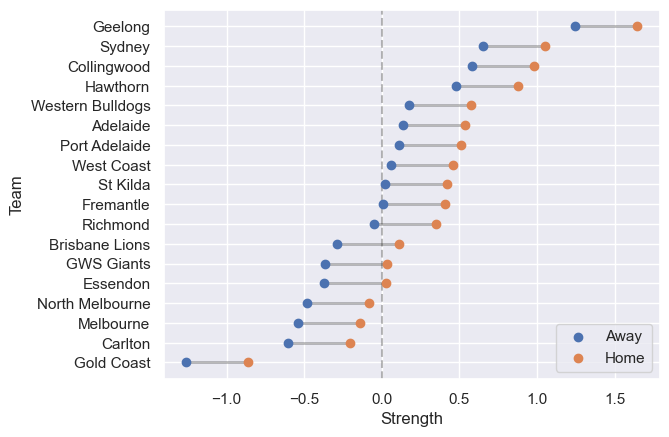

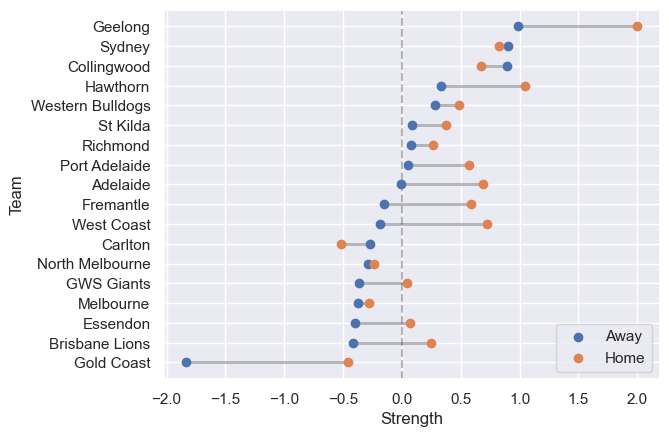

In [54]:
for model in (cha_nom, tsa_nom):
    plt.figure(figsize=(10, 6))
    ax = plot_strengths(model)
    ax = plt.gca()
    sns.move_legend(ax, "upper right", bbox_to_anchor=(-0.08, 1))
    plt.title(f"AFL Parameter Estimates ({model.__class__.__name__})")
    # plt.savefig(f"ch4_afl_basic_{model.__class__.__name__}", bbox_inches="tight")
    # plt.xticks(rotation=90)
    plt.show()

for model in (cha_nom, tsa_nom):
    plot_strengths(model, 'average', mean_centered=True)
    # plt.savefig(f"ch4_afl_basic_{model.__class__.__name__}_avg", bbox_inches="tight")
    plt.show()

In [52]:
simple_report(van, cha_nom)
simple_report(cha_nom, tsa_nom)
simple_report(van, tsa_nom)
print()

Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
VANBT      327   2068.68      4791.37      6847.06     
CHABT      328   2015.47      4686.94      6748.92      106.429    5.94e-25 ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
CHABT      328   2015.47      4686.94      6748.92     
TSABT      345   1990.59      4671.18      6840.03      49.757     4.61e-05 ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
VANBT      327   2068.68      4791.37      6847.06     
TSABT      345   1990.59      4671.18      6840.03      156.186    4.64e-24 ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1



## Hierarchical model fitting

We've looked at some basic models for HGA in AFL and their procedures.
Next, we'd like to analyse some more complex ideas for HGA models.
The hierarchical BT models allow us to specify *relationships* between teams that dictate how HGA exists.

This might be a little conceptually difficult at first, so let's start with a simple example.
Previously, we've had models for a common HGA for all teams (CHA) and a unique HGA for each team (TSA).
Due to the history of the AFL, 10 out of the 18 teams are Victorian (i.e., their home-ground is located in Victoria).
Therefore, an interesting middle-ground would be to see how HGA varies between the Victorian teams and non-Victorian teams.

The relationship $r_{ij}$ between teams $i$ and $j$ essentially denotes the index of the HGA parameter to use.
We assume the first index is the home team (e.g., $i$ is home for $r_{ij}$).
These are compiled into a single *relationship matrix* $R = [r_{ij}]$ which gets passed to the model alongside the usual data.

There are a few different ways we could explore our simple scenario:
- Within vs across: $\alpha_1$ for (vic-vic OR nonvic-nonvic) and $\alpha_2$ for vic-nonvic
- Within vs across, split: $\alpha_1$ for vic-vic, $\alpha_2$ for nonvic-nonvic, $\alpha_3$ for vic-nonvic, and $\alpha_4$ for nonvic-vic
- Group-specific: $\alpha_1$ for vic at home and $\alpha_2$ for nonvic at home

Let's generate these different rel mats and visualise them.

In [131]:
states = team_locations.state.to_dict()

# Generate the relationship matrices for the hierarhical models
teams = list(states.keys())
groups = np.array([states[t] for t in teams])
I = len(teams)

is_vic = (groups == "Victoria")

In [132]:
## State-wise relationships

# State-specific HGA
# state_specific = team_locations.state.astype("category").cat.codes.to_numpy() + 1
state_specific = team_locations.state.astype("category").to_numpy()
state_specific = state_specific.repeat(I).reshape(I, I)
np.fill_diagonal(state_specific, 0)
state_specific = DataFrame(state_specific, index=teams, columns=teams)


# Within vs across state
states = team_locations.state.to_numpy()
same_state  = states[:, None]  == states[None, :]
matrix = np.where(
    same_state, 1,
    2
)
np.fill_diagonal(matrix, 0)
states_sym = DataFrame(matrix, index=teams, columns=teams)

In [ ]:
hie1 = HIEBT().fit(basic_hga, state_specific)

In [101]:
hie2 = HIEBT().fit(df_nom_hga, state_specific)

In [168]:
dummy1 = hie1.get_hgas(include_errors=True).reset_index().rename(columns={"index": "State"})
dummy1["Type"] = "Allow Neutral"
dummy2 = hie2.get_hgas(include_errors=True).reset_index().rename(columns={"index": "State"})
dummy2["Type"] = "Nominal Home"
dummy = pd.concat([dummy1, dummy2]).reset_index(drop=True)

# dummy.sort_values(["State", "Type"], inplace=True, ascending=True)
# dummy.reset_index(inplace=True, drop=True)
dummy

,State,HGA,[SE],Type
0,New South Wales,0.355955,0.182716,Allow Neutral
1,Queensland,0.686806,0.185030,Allow Neutral
2,South Australia,0.515112,0.173536,Allow Neutral
3,Victoria,0.425144,0.089156,Allow Neutral
4,Western Australia,0.938903,0.183780,Allow Neutral
5,New South Wales,0.422331,0.181650,Nominal Home
6,Queensland,0.834607,0.169785,Nominal Home
7,South Australia,0.610159,0.158477,Nominal Home
8,Victoria,0.182710,0.063863,Nominal Home
9,Western Australia,0.811843,0.166484,Nominal Home


In [178]:
simple_report(cha, hie1)
simple_report(hie1, tsa)
simple_report(cha_nom, hie2)
simple_report(hie2, tsa_nom)
print()

Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
CHABT      328   2005.46      4666.91      6728.89     
HIEBT      332   2001.88      4667.76      6754.88      7.157      0.128 

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
HIEBT      332   2001.88      4667.76      6754.88     
TSABT      345   1994.40      4678.81      6847.66      14.947     0.311 

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
CHABT      328   2015.47      4686.94      6748.92     
HIEBT      332   2004.58      4673.15      6760.28      21.786     2.21e-04 ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Terry Mo

In [212]:
## VIC vs nonVIC
cities = team_locations.city.to_dict().values()
is_melb = (np.array([i for i in cities]) == "Melbourne")

# 1) Within-vs-across
same_group = is_melb[:, None] == is_melb[None, :]
relmat1 = np.where(same_group, 1, 2)
np.fill_diagonal(relmat1, 0)


# 2) Within-vs-across, split
base = is_melb * 2
same_vic = is_melb[:, None] == is_melb[None, :]
relmat2 = np.where(
    same_vic,
    base[:, None] + 1,
    base[:, None] + 2
)
np.fill_diagonal(relmat2, 0)


# 3) Group-specific: vic vs nonvic
relmat3 = np.where(is_melb[:, None], 1, 2).repeat(I, axis=1)
np.fill_diagonal(relmat3, 0)


relmat1 = DataFrame(relmat1, index=teams, columns=teams)
relmat2 = DataFrame(relmat2, index=teams, columns=teams)
relmat3 = DataFrame(relmat3, index=teams, columns=teams)

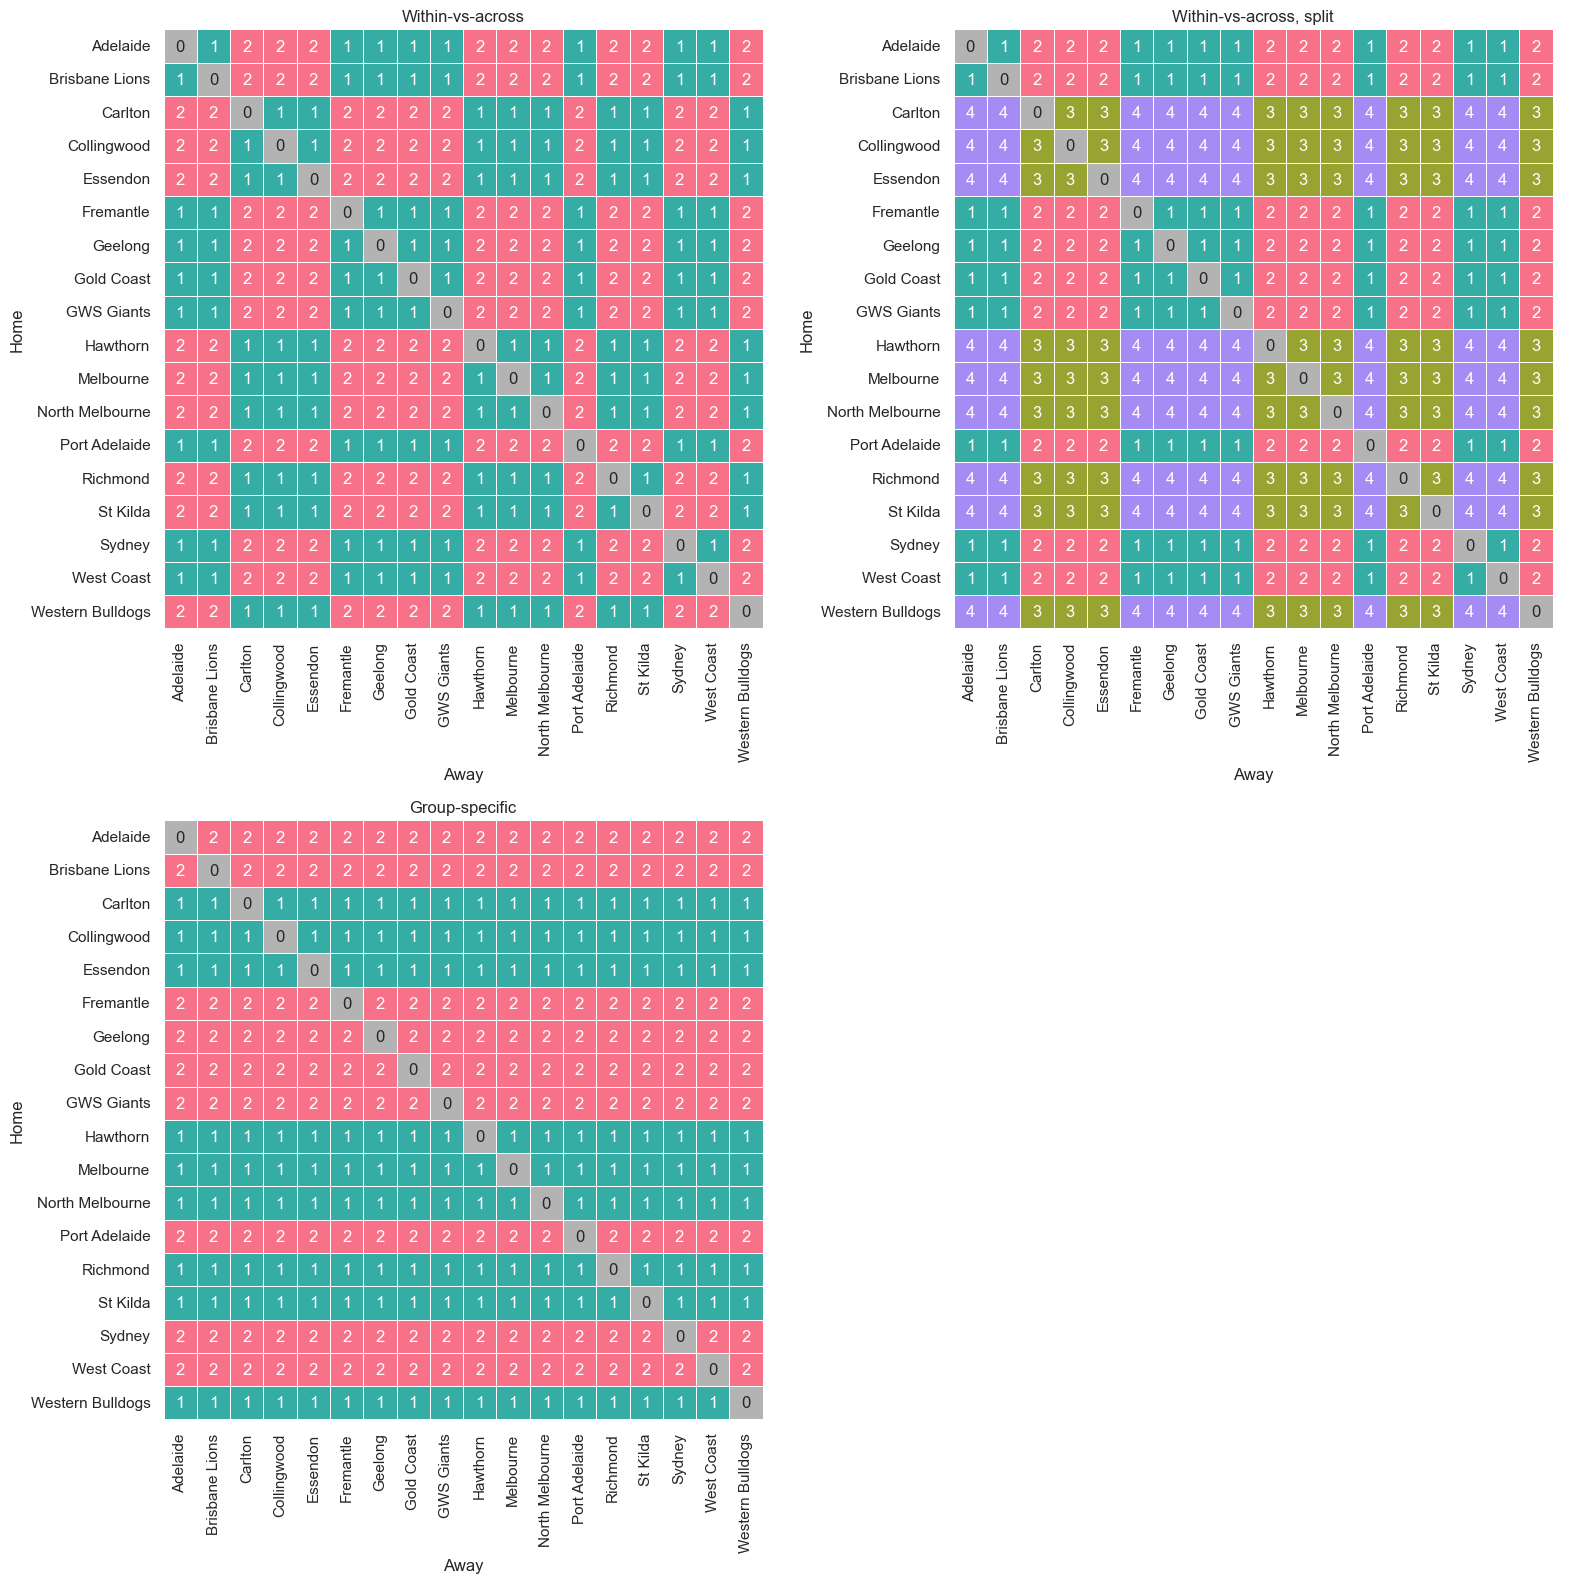

In [213]:
relmats = [relmat1, relmat2, relmat3]
titles = ["Within-vs-across", "Within-vs-across, split", "Group-specific"]

plot_relmat_grid(relmats, titles, ncols=2, scale=2)
plt.show()

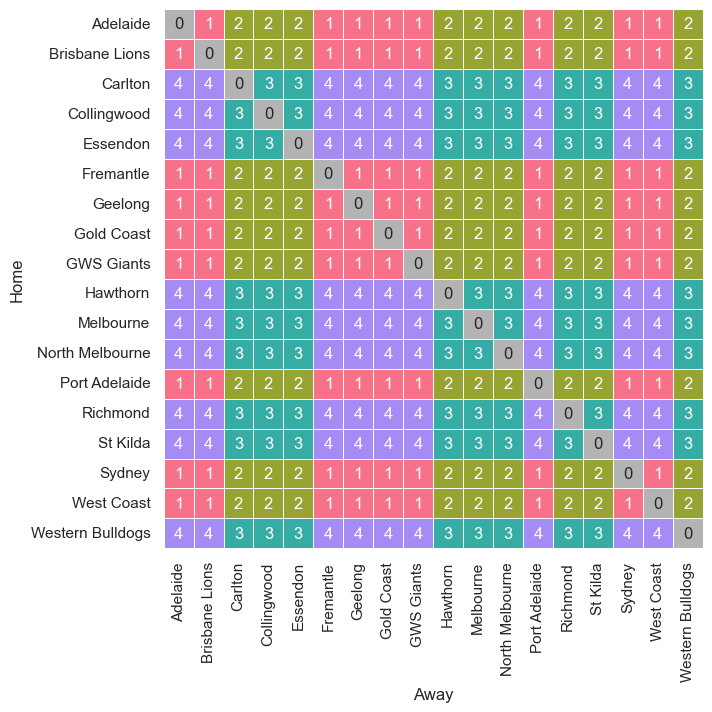

In [221]:
plot_single_relmat(relmat2, (7,7))

The zeroes along the main diagonal are just null values in this case, they get ignored in the model as teams don't play themselves. Using something like `np.nan` would also be fine but converts the other entries to floats which might seem a bit ugly.

In [ ]:
hie3 = HIEBT().fit(df_nom_hga, relmat1)

In [215]:
hie4 = HIEBT().fit(df_nom_hga, relmat2)

In [ ]:
hie5 = HIEBT().fit(df_nom_hga, relmat3)

In [225]:
hie4.summary()

MODEL SUMMARY: HIEBT

Model Statistics
-------------------------
# Teams:   18              # Obs:     3970
# Times:   20              # Params:  331
LLH:       -2001.833
AIC:       4665.666
BIC:       6746.504
# Iter:    53

Constraint team: Adelaide

Team Rankings
-------------------------
                      2005    [SE_2005]      2006    [SE_2006]      2007    [SE_2007]      2008  \
Geelong             -0.970        0.652    -1.335        0.685     1.565        0.704     2.378   
Collingwood         -2.447  2034536.284    -0.628  2034536.284     0.389  2034536.284     0.187   
Hawthorn            -2.395  2034536.284    -1.636  2034536.284     0.422  2034536.284     1.582   
Sydney              -0.072        0.647    -0.545        0.661    -0.040        0.641     0.087   
Western Bulldogs    -0.960  2034536.284    -0.523  2034536.284    -0.266  2034536.284     0.836   
St Kilda            -0.459  2034536.284    -0.421  2034536.284     0.001  2034536.284     0.314   
Richmond      

'====================================================================================================\nMODEL SUMMARY: HIEBT\n====================================================================================================\n\nModel Statistics\n-------------------------\n# Teams:   18              # Obs:     3970\n# Times:   20              # Params:  331\nLLH:       -2001.833\nAIC:       4665.666\nBIC:       6746.504\n# Iter:    53\n\nConstraint team: Adelaide\n\nTeam Rankings\n-------------------------\n                      2005    [SE_2005]      2006    [SE_2006]      2007    [SE_2007]      2008  \\\nGeelong             -0.970        0.652    -1.335        0.685     1.565        0.704     2.378   \nCollingwood         -2.447  2034536.284    -0.628  2034536.284     0.389  2034536.284     0.187   \nHawthorn            -2.395  2034536.284    -1.636  2034536.284     0.422  2034536.284     1.582   \nSydney              -0.072        0.647    -0.545        0.661    -0.040        0.641 

<Axes: >

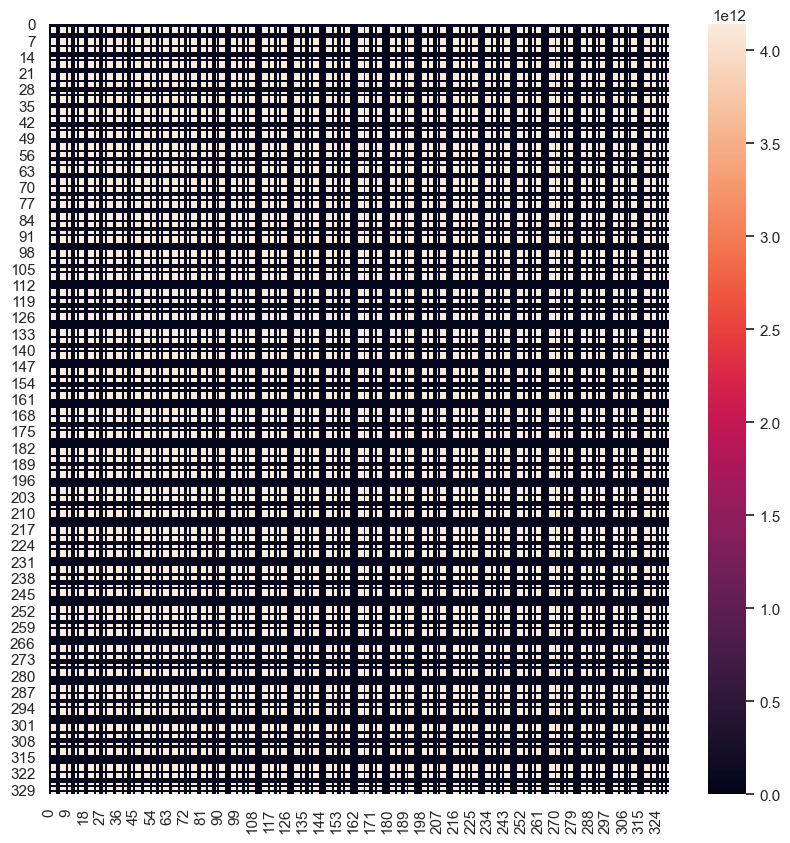

In [230]:
plt.figure(figsize=(10,10))
sns.heatmap(np.abs(hie4._hess_inv - hie4._fit_summary.hess_inv))

In [282]:
est_hess = hie4._fit_summary.hess_inv
est_errs = np.sqrt(np.maximum(np.diag(est_hess), 0))
for idx in sorted(hie4._inactive_idxs):
    est_errs = np.insert(est_errs, idx, np.nan)
hie4.errors = est_errs

In [284]:
hie4.summary()

MODEL SUMMARY: HIEBT

Model Statistics
-------------------------
# Teams:   18              # Obs:     3970
# Times:   20              # Params:  331
LLH:       -2001.833
AIC:       4665.666
BIC:       6746.504
# Iter:    53

Constraint team: Adelaide

Team Rankings
-------------------------
                      2005  [SE_2005]      2006  [SE_2006]      2007  [SE_2007]      2008  \
Geelong             -0.970      0.939    -1.335      1.007     1.565      0.975     2.378   
Collingwood         -2.447      0.996    -0.628      0.995     0.389      0.913     0.187   
Hawthorn            -2.395      0.997    -1.636      1.002     0.422      0.705     1.582   
Sydney              -0.072      0.985    -0.545      0.994    -0.040      0.938     0.087   
Western Bulldogs    -0.960      0.988    -0.523      1.000    -0.266      0.985     0.836   
St Kilda            -0.459      0.977    -0.421      0.996     0.001      0.971     0.314   
Richmond            -1.353      0.990    -1.007      1.0

'====================================================================================================\nMODEL SUMMARY: HIEBT\n====================================================================================================\n\nModel Statistics\n-------------------------\n# Teams:   18              # Obs:     3970\n# Times:   20              # Params:  331\nLLH:       -2001.833\nAIC:       4665.666\nBIC:       6746.504\n# Iter:    53\n\nConstraint team: Adelaide\n\nTeam Rankings\n-------------------------\n                      2005  [SE_2005]      2006  [SE_2006]      2007  [SE_2007]      2008  \\\nGeelong             -0.970      0.939    -1.335      1.007     1.565      0.975     2.378   \nCollingwood         -2.447      0.996    -0.628      0.995     0.389      0.913     0.187   \nHawthorn            -2.395      0.997    -1.636      1.002     0.422      0.705     1.582   \nSydney              -0.072      0.985    -0.545      0.994    -0.040      0.938     0.087   \nWestern Bulldogs

In [283]:
hie4.get_hgas(include_errors=True)

,HGA,[SE]
1,0.515673,0.075252
2,0.745703,0.128743
3,0.054004,0.069841
4,0.304952,0.130999


We can do hypothesis testing on these models as well by noting that the CHA model is nested in all of them.

In [291]:
simple_report(cha_nom, hie4)

Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
CHABT      328   2015.47      4686.94      6748.92     
HIEBT      331   2001.83      4665.67      6746.50      27.274     5.16e-06 ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


{'m1': {'name': 'CHABT',
  'n_times': 20,
  'aic': np.float64(4686.939665355199),
  'bic': np.float64(6748.918675922644)},
 'm2': {'name': 'HIEBT',
  'n_times': 20,
  'aic': np.float64(4665.665919082077),
  'bic': np.float64(6746.504493770566)},
 'lrt': {'stat': np.float64(27.27374627312156),
  'df': 3,
  'p_value': np.float64(5.158478040534286e-06)}}

In [75]:
simple_report(cha, hie1)
simple_report(hie1, hie2)
simple_report(cha, hie3)
simple_report(hie3, tsa)
print()

Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
CHABT      328   2005.46      4666.91      6728.89     
HIEBT      329   2005.45      4668.90      6737.16      0.015      0.901 

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
HIEBT      329   2005.45      4668.90      6737.16     
HIEBT      331   2003.95      4669.91      6750.75      2.989      0.224 

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
CHABT      328   2005.46      4666.91      6728.89     
HIEBT      329   2004.52      4667.03      6735.30      1.878      0.171 

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Terry Model Co

There doesn't seem to be any evidence of different HGAs for within and across the groups.
However, there does seem to be moderate evidence ($p < 0.02$) of a difference between HGA for Vic and non-Vic teams.
This is quite an interesting result!
Compared to the asymmetric model, the TSA model from before doesn't offer a better fit.
Hence, in our framework, we are inclined to conclude that the asymmetric model `hie3` is suitable for modelling the AFL competition from 2005-2024.

## Static and Fully Dynamic Models (previous work)

The main addition of this work compared to previous is the allowance of *dynamic* team strengths (while HGAs are constant).
As such, we are interested in comparing these dynamic models with their static counterparts.

In [251]:
df_nom = df.copy()
df_nom.is_neutral = 0

In [252]:
# Testing static models over 3-year windows from 2010-2019

start, end = 2010, 2019
window_length = 3
windows = [(y, y+window_length-1) for y in range(start, end-1)]
results = {}

for w in windows:
    w1, w2 = w

    # Make data
    df_st = df_nom[(w1 <= df_nom.year) & (df_nom.year <= w2)].drop("venue", axis=1)
    # dynamic_van = make_time_blocked_win_matrix(df_st)
    dynamic_hga = make_time_blocked_venue_win_matrices(df_st)

    df_st["time"] = 1
    # static_van = make_time_blocked_win_matrix(df_st)
    static_hga = make_time_blocked_venue_win_matrices(df_st)
    
    # Fit models
    dycha = CHABT().fit(dynamic_hga)
    stcha = CHABT().fit(static_hga)

    results[w] = compare_deviances(stcha, dycha)

In [253]:
# Cleaning up the results for presentation

results_df = (
    DataFrame.from_dict(results, orient="index")
    .rename_axis(["start", "end"])
    .reset_index()
)
results_df["sig"] = results_df["p_value"].apply(
    lambda p: "***" if p <= 0.001 else
              "**"  if p <= 0.01  else
              "*"   if p <= 0.05  else
              "."   if p <= 0.1   else ""
)
results_df.p_value = results_df.p_value.apply(
    lambda p: f"{p:.2e}" if p < 0.001 else f"{p:.3f}"
)
results_df.stat = results_df.stat.round(1)
results_df

,start,end,stat,df,p_value,sig
0,2010,2012,89.5,31,1.39e-07,***
1,2011,2013,91.7,33,1.95e-07,***
2,2012,2014,60.9,34,0.003,**
3,2013,2015,72.5,34,1.35e-04,***
4,2014,2016,101.9,34,1.06e-08,***
5,2015,2017,76.5,34,4.13e-05,***
6,2016,2018,77.5,34,3.00e-05,***
7,2017,2019,59.3,34,0.005,**


In [255]:
def dummy_model_stats(models: list[BaseBradleyTerry]):
    llh = sum([m._fit_summary.fun for m in models])
    df = sum([m.n_params_active for m in models])
    return llh, df

def quick_comparison(dynamics, static):
    dyllh, dydf = dummy_model_stats(dynamics)
    D_value = calculate_deviance_test_stat(static._fit_summary.fun, dyllh)
    df = dydf - static.n_params_active

    if df <= 0:
        raise ValueError("Model M1 must have less parameters than M2.")

    p_val = chi2.sf(D_value, df)
    p_val_text = f"{p_val:.2e}" if p_val < 0.001 else f"{p_val:.3f}"

    print(f"D={D_value:.3f} on {df} df, p={p_val_text}")

In [267]:
# Testing home-ground advantage as well
fully_dycha = []
for y in range(start, end+1):
    df_full = df_nom[df_nom.year == y].drop("venue", axis=1)
    # dynamic_van = make_time_blocked_win_matrix(df_st)
    dynamic_hga = make_time_blocked_venue_win_matrices(df_full)
    m = CHABT().fit(dynamic_hga)
    fully_dycha.append(m)

In [272]:
dummy = df_nom[(start <= df_nom.year) & (df_nom.year <= end)].drop("venue", axis=1)
dycha2 = CHABT().fit(make_time_blocked_venue_win_matrices(dummy))

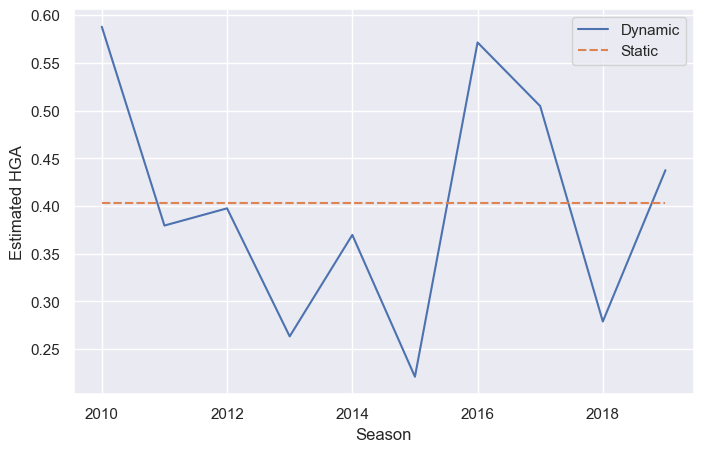

In [296]:
dummy_hgas = {m.times[0]: m.get_param("hga") for m in fully_dycha}
# for m in fully_dycha: m.get_hgas()
dummy_hgas = DataFrame.from_dict(dummy_hgas, orient="index", columns=["Dynamic"])
dummy_hgas["Static"] = dycha2.get_param("hga")

plt.figure(figsize=(8, 5))
sns.lineplot(dummy_hgas)
plt.xlabel("Season")
plt.ylabel("Estimated HGA")
plt.show()

In [292]:
quick_comparison(fully_dycha, dycha2)

D=4.504 on 9 df, p=0.875


In [293]:
# Testing home-ground advantage as well
fully_dytsa = []
for y in range(start, end+1):
    df_full = df_nom[df_nom.year == y].drop("venue", axis=1)
    # dynamic_van = make_time_blocked_win_matrix(df_st)
    dynamic_hga = make_time_blocked_venue_win_matrices(df_full)
    m = TSABT().fit(dynamic_hga)
    fully_dytsa.append(m)

dytsa2 = TSABT().fit(make_time_blocked_venue_win_matrices(dummy))

In [294]:
quick_comparison(fully_dytsa, dytsa2)

D=173.352 on 159 df, p=0.206


## Case study: COVID-19

We're interested in analysing the years shortly before and after the COVID-19 pandemic to see if HGA changed significantly over this period.
Many changes were implemented into the competition due to lockdowns, such as cancelling games, moving matches to other venues, and employing "ghost games" where fans are not present.

In [ ]:
# Baseline with vanilla models
covid_before_van = {i: df_nom_van[i] for i in range(2017, 2020)}
covid_during_van = {i: df_nom_van[i] for i in range(2020, 2022)}
covid_after_van = {i: df_nom_van[i] for i in range(2022, 2025)}

covid_not_during_van = covid_before_van | covid_after_van
covid_all_van = covid_not_during_van | covid_during_van

van_covid_before = VANBT().fit(covid_before_van)
van_covid_during = VANBT().fit(covid_during_van)
van_covid_after = VANBT().fit(covid_after_van)

van_covid_static = VANBT().fit(covid_not_during_van)
van_covid_all = VANBT().fit(covid_all_van)

In [112]:
# Make our windows of data to examine
covid_before = {i: df_nom_hga[i] for i in range(2017, 2020)}
covid_during = {i: df_nom_hga[i] for i in range(2020, 2022)}
covid_after = {i: df_nom_hga[i] for i in range(2022, 2025)}

covid_not_during = covid_before | covid_after
covid_all = covid_not_during | covid_during

In [ ]:
# Common HGA
cha_covid_before = CHABT().fit(covid_before)
cha_covid_during = CHABT().fit(covid_during)
cha_covid_after = CHABT().fit(covid_after)

cha_covid_static = CHABT().fit(covid_not_during)
cha_covid_all = CHABT().fit(covid_all)

In [117]:
# spin up a model for doing manual hypothesis testing

def dummy_model_stats(models: list[BaseBradleyTerry]):
    llh = sum([m._fit_summary.fun for m in models])
    df = sum([m.n_params_active for m in models])
    return llh, df

def quick_comparison(dynamics, static):
    dyllh, dydf = dummy_model_stats(dynamics)
    D_value = calculate_deviance_test_stat(static._fit_summary.fun, dyllh)
    df = dydf - static.n_params_active

    if df <= 0:
        raise ValueError("Model M1 must have less parameters than M2.")

    p_val = chi2.sf(D_value, df)
    p_val_text = f"{p_val:.2e}" if p_val < 0.001 else f"{p_val:.3f}"

    print(f"D={D_value:.3f} on {df} df, p={p_val_text}")

In [ ]:
# Team-specific HGA
tsa_covid_before = TSABT().fit(covid_before)
tsa_covid_during = TSABT().fit(covid_during)
tsa_covid_after = TSABT().fit(covid_after)

# Compared to models just assuming it's constant
tsa_covid_static = TSABT().fit(covid_not_during)
tsa_covid_all = TSABT().fit(covid_all)

In [133]:
# State-specific HGA
ssa_covid_before = HIEBT().fit(covid_before, state_specific)
ssa_covid_during = HIEBT().fit(covid_during, state_specific)
ssa_covid_after = HIEBT().fit(covid_after, state_specific)

# Compared to models just assuming it's constant
ssa_covid_static = HIEBT().fit(covid_not_during, state_specific)
ssa_covid_all = HIEBT().fit(covid_all, state_specific)

In [149]:
_ = simple_report(van_covid_all, cha_covid_all)
_ = simple_report(van_covid_static, cha_covid_static)

_ = simple_report(cha_covid_all, ssa_covid_all)
_ = simple_report(cha_covid_static, ssa_covid_static)

_ = simple_report(cha_covid_all, tsa_covid_all)
_ = simple_report(cha_covid_static, tsa_covid_static)

Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
VANBT      136   886.96       2045.93      2779.75     
CHABT      137   868.62       2011.24      2750.46      36.685     1.39e-09 ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
VANBT      102   685.89       1575.77      2099.94     
CHABT      103   667.64       1541.28      2070.58      36.491     1.53e-09 ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
CHABT      137   868.62       2011.24      2750.46     
HIEBT      141   864.29       2010.58      2771.38      8.664      0.070 .

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-T

In [163]:
quick_comparison((cha_covid_static, cha_covid_during), cha_covid_all)
quick_comparison((ssa_covid_static, ssa_covid_during), ssa_covid_all)
quick_comparison((tsa_covid_static, tsa_covid_during), tsa_covid_all)

D=2.244 on 1 df, p=0.134
D=10.851 on 5 df, p=0.054
D=21.162 on 18 df, p=0.271


In [135]:
# Testing - need to do it manually because models are separated

quick_comparison((cha_covid_before, cha_covid_during, cha_covid_after), cha_covid_all)
quick_comparison((cha_covid_before, cha_covid_after), cha_covid_static)

quick_comparison((ssa_covid_before, ssa_covid_during, ssa_covid_after), ssa_covid_all)
quick_comparison((ssa_covid_before, ssa_covid_after), ssa_covid_static)

quick_comparison((tsa_covid_before, tsa_covid_during, tsa_covid_after), tsa_covid_all)
quick_comparison((tsa_covid_before, tsa_covid_after), tsa_covid_static)


D=2.868 on 2 df, p=0.238
D=0.624 on 1 df, p=0.430
D=24.992 on 10 df, p=0.005
D=14.141 on 5 df, p=0.015
D=50.107 on 36 df, p=0.059
D=28.945 on 18 df, p=0.049


In [161]:
print(cha_covid_before.get_hgas("hga").round(3))
print(cha_covid_during.get_hgas("hga").round(3))
print(cha_covid_after.get_hgas("hga").round(3))

print(cha_covid_static.get_hgas("hga").round(3))
print(cha_covid_all.get_hgas("hga").round(3))

          HGA   [SE]
Common  0.352  0.095
          HGA   [SE]
Common  0.192  0.123
          HGA   [SE]
Common  0.459  0.097
          HGA   [SE]
Common  0.404  0.068
          HGA   [SE]
Common  0.356  0.059


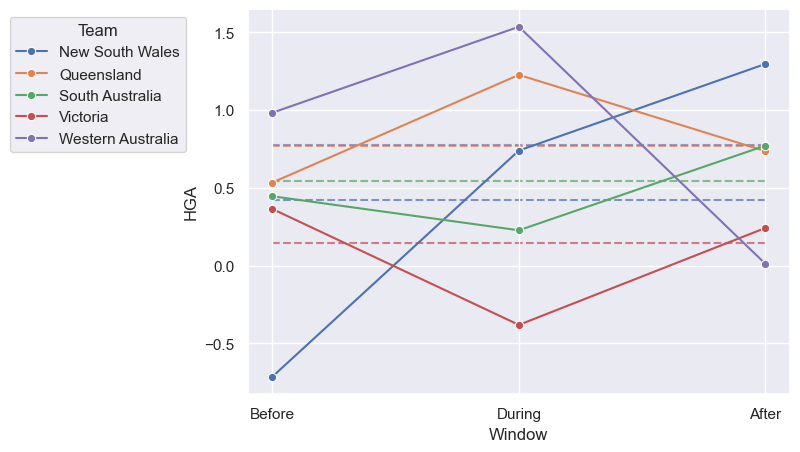

In [170]:
models = (ssa_covid_before, ssa_covid_during, ssa_covid_after)
combined = pd.concat(
    [mod.get_hgas()["HGA"] for mod in models],
    axis=1
)

combined.columns = ["Before", "During", "After"]

long = (
    combined
    .reset_index()                 # bring team out of index
    .rename(columns={"index": "Team"})
    .melt(id_vars="Team", var_name="Window", value_name="HGA")
)

hga_all = ssa_covid_all.get_hgas()["HGA"]
ref = (
    pd.concat([hga_all]*len(combined.columns), axis=1)
    .set_axis(combined.columns, axis=1)
    .reset_index()
    .rename(columns={"index": "Team"})
    .melt(id_vars="Team", var_name="Window", value_name="HGA")
)

plt.figure(figsize=(7, 5))
ax = sns.lineplot(
    data=long,
    x="Window",
    y="HGA",
    hue="Team",
    marker="o"
)
sns.lineplot(
    data=ref,
    x="Window",
    y="HGA",
    hue="Team",
    linestyle="--",
    legend=False,   # avoid duplicate legend
    zorder=-1,
    alpha=0.7,
    ax=ax
)
sns.move_legend(ax, "upper right", bbox_to_anchor=(-0.1, 1))
plt.show()

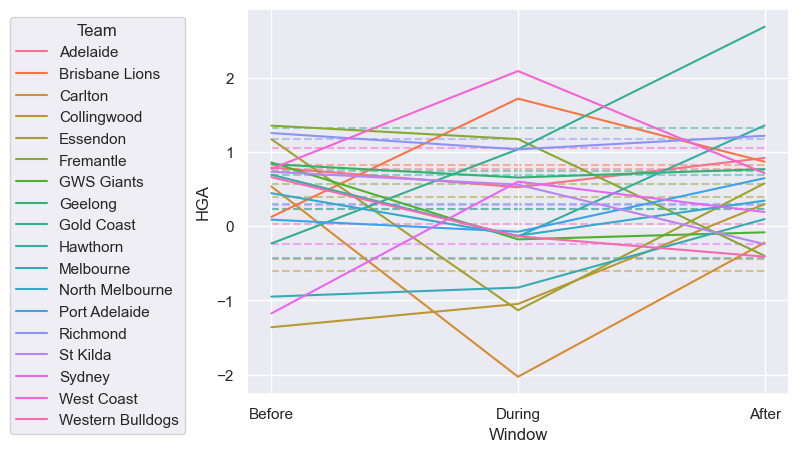

In [174]:
models = (tsa_covid_before, tsa_covid_during, tsa_covid_after)
combined = pd.concat(
    [mod.get_hgas()["HGA"] for mod in models],
    axis=1
)

combined.columns = ["Before", "During", "After"]

long = (
    combined
    .reset_index()                 # bring team out of index
    .rename(columns={"index": "Team"})
    .melt(id_vars="Team", var_name="Window", value_name="HGA")
)

hga_all = tsa_covid_all.get_hgas()["HGA"]
ref = (
    pd.concat([hga_all]*len(combined.columns), axis=1)
    .set_axis(combined.columns, axis=1)
    .reset_index()
    .rename(columns={"index": "Team"})
    .melt(id_vars="Team", var_name="Window", value_name="HGA")
)

plt.figure(figsize=(7, 5))
ax = sns.lineplot(
    data=long,
    x="Window",
    y="HGA",
    hue="Team",
    # marker="o"
)
sns.lineplot(
    data=ref,
    x="Window",
    y="HGA",
    hue="Team",
    linestyle="--",
    legend=False,   # avoid duplicate legend
    zorder=-1,
    alpha=0.5,
    ax=ax
)
sns.move_legend(ax, "upper right", bbox_to_anchor=(-0.1, 1))
plt.show()

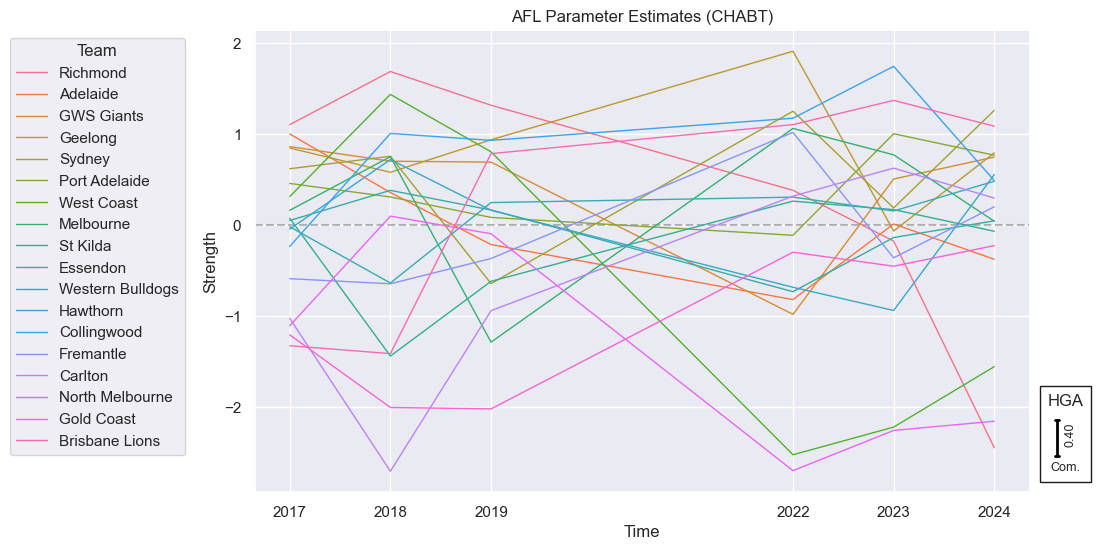

In [129]:
plt.figure(figsize=(10, 6))
ax = plot_strengths(cha_covid_static)
ax = plt.gca()
sns.move_legend(ax, "upper right", bbox_to_anchor=(-0.08, 1))
plt.title(f"AFL Parameter Estimates ({cha_covid_static.__class__.__name__})")
# plt.savefig(f"ch4_afl_basic_{model.__class__.__name__}", bbox_inches="tight")
# plt.xticks(rotation=90)
plt.show()

## Calculation Testing

To demonstrate how an non-statistical user can easily interpret the models, we can calculate the estimated win probabilities for some given team of interest.
A quick example is given below, where we condense all the win probs over the time period for *Richmond* into a heatmap.
There's an option to choose which team gets HGA but note that some configurations are impossible (namely when Richmond plays another MCG tenant, as any match between those teams will always be considered 'neutral' to us).

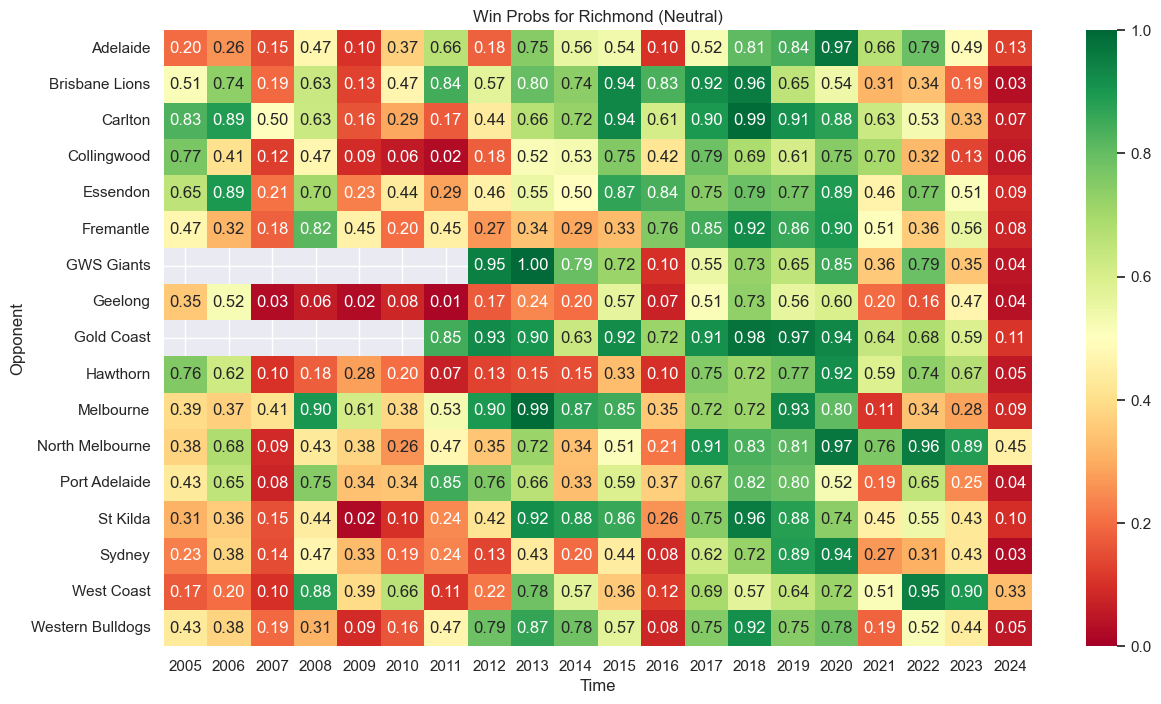

In [112]:
team_of_interest = "Richmond"
venue = "neutral"
model = cha

opponents = [t for t in model.teams if t != team_of_interest]
prob_matrix = np.zeros((len(opponents), model.n_times))

for t_idx, time in enumerate(model.times):
    for o_idx, opponent in enumerate(opponents):
        prob_matrix[o_idx, t_idx] = model.get_prob(team_of_interest, opponent, time, venue)
        
df_probs = DataFrame(prob_matrix, index=opponents, columns=model.times)

plt.figure(figsize=(14, 8))
sns.heatmap(df_probs, annot=True, fmt=".2f", cmap="RdYlGn", center=0.5, vmin=0, vmax=1)
plt.title(f"Win Probs for {team_of_interest} ({venue.capitalize()})")
plt.xlabel("Time")
plt.ylabel("Opponent")
plt.show()